# E-Commerce Sales Analytics Dashboard

## Project Overview

This project analyzes a global e-commerce sales dataset to understand sales performance, profitability, customer behavior, product performance, and regional trends.

The objective is to identify key business insights that can help improve sales strategies, optimize discounts, and increase profitability.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Power BI
- SQL

## Business Questions

1. Which categories generate the highest sales?
2. Which categories generate the highest profit?
3. Who are the top customers?
4. Which products perform best?
5. Which regions contribute most to sales?
6. How do discounts affect profitability?
7. What are the major business opportunities?

## Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

pd.set_option('display.max_columns', None)

## Load Dataset

In [8]:
df = pd.read_csv(
    'superstore_cleaned_complete.csv',
    low_memory=False
)

## Check Dataset

In [10]:
df.head()

,category,city,country,customer_id,customer_name,discount,market,column,order_date,order_id,order_priority,product_id,product_name,profit,quantity,region,sales,segment,ship_date,ship_mode,shipping_cost,state,sub_category,order_year,order_month,order_quarter,order_day_of_week,is_weekend,order_week,discount_bin,profit_margin,sales_per_unit
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,Us,1,1/7/2011,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.3312,3,West,19,Consumer,1/9/2011,Second Class,4.37,California,Paper,2011,1,1,4,0,1,0-5%,49.11,6.33
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,Us,1,1/21/2011,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" X 4""",9.2928,2,West,19,Consumer,1/26/2011,Standard Class,0.94,California,Paper,2011,1,1,4,0,3,0-5%,48.91,9.50
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,Us,1,8/5/2011,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Me...",9.8418,3,West,21,Consumer,8/9/2011,Standard Class,1.81,California,Paper,2011,8,3,4,0,31,0-5%,46.87,7.00
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,Us,1,8/5/2011,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.2608,2,West,111,Consumer,8/9/2011,Standard Class,4.59,California,Paper,2011,8,3,4,0,31,0-5%,47.98,55.50
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,Us,1,9/29/2011,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.1104,1,West,6,Consumer,10/3/2011,Standard Class,1.32,California,Paper,2011,9,3,3,0,39,0-5%,51.84,6.00


## Dataset Shape

In [12]:
df.shape

(51290, 32)

The dataset contains 51290 rows and 32 columns.

## Data overview

## Column Information

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   category           51290 non-null  object 
 1   city               51290 non-null  object 
 2   country            51290 non-null  object 
 3   customer_id        51290 non-null  object 
 4   customer_name      51290 non-null  object 
 5   discount           51290 non-null  float64
 6   market             51290 non-null  object 
 7   column             51290 non-null  int64  
 8   order_date         51290 non-null  object 
 9   order_id           51290 non-null  object 
 10  order_priority     51290 non-null  object 
 11  product_id         51290 non-null  object 
 12  product_name       51290 non-null  object 
 13  profit             51290 non-null  float64
 14  quantity           51290 non-null  int64  
 15  region             51290 non-null  object 
 16  sales              512

## Statiscal Summary

In [87]:
df.describe()

,discount,column,profit,quantity,sales,shipping_cost,order_year,order_month,order_quarter,order_day_of_week,is_weekend,order_week,profit_margin,sales_per_unit
count,51290.000000,51290.0,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51289.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,246.498440,26.375818,2012.777208,7.522636,2.793235,2.343264,0.108598,30.675687,4.719982,71.659962
std,0.212280,0.0,174.340972,2.278766,487.567175,57.296810,1.098931,3.300056,1.066015,1.671486,0.311137,14.535168,46.684923,113.581091
min,0.000000,1.0,-6599.978000,1.000000,0.000000,0.002000,2011.000000,1.000000,1.000000,0.000000,0.000000,1.000000,-472.780000,0.000000
25%,0.000000,1.0,0.000000,2.000000,31.000000,2.610000,2012.000000,5.000000,2.000000,1.000000,0.000000,20.000000,0.000000,12.000000
50%,0.000000,1.0,9.240000,3.000000,85.000000,7.790000,2013.000000,8.000000,3.000000,2.000000,0.000000,33.000000,16.930000,29.500000
75%,0.200000,1.0,36.810000,5.000000,251.000000,24.450000,2014.000000,10.000000,4.000000,4.000000,0.000000,44.000000,33.310000,82.000000
max,0.850000,1.0,8399.976000,14.000000,22638.000000,933.570000,2014.000000,12.000000,4.000000,6.000000,1.000000,52.000000,58.280000,3773.000000


## Missing Values

In [17]:
df.isnull().sum()

category             0
city                 0
country              0
customer_id          0
customer_name        0
discount             0
market               0
column               0
order_date           0
order_id             0
order_priority       0
product_id           0
product_name         0
profit               0
quantity             0
region               0
sales                0
segment              0
ship_date            0
ship_mode            0
shipping_cost        0
state                0
sub_category         0
order_year           0
order_month          0
order_quarter        0
order_day_of_week    0
is_weekend           0
order_week           0
discount_bin         0
profit_margin        0
sales_per_unit       0
dtype: int64

## Duplicate Records

In [19]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning

The dataset was checked for:

- Missing values
- Duplicate records
- Data type consistency

No major data quality issues were identified.

# Exploratory Data Analysis (EDA)

## Analysis 1: Sales by Category

In [24]:
category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)

category_sales

category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: sales, dtype: int64

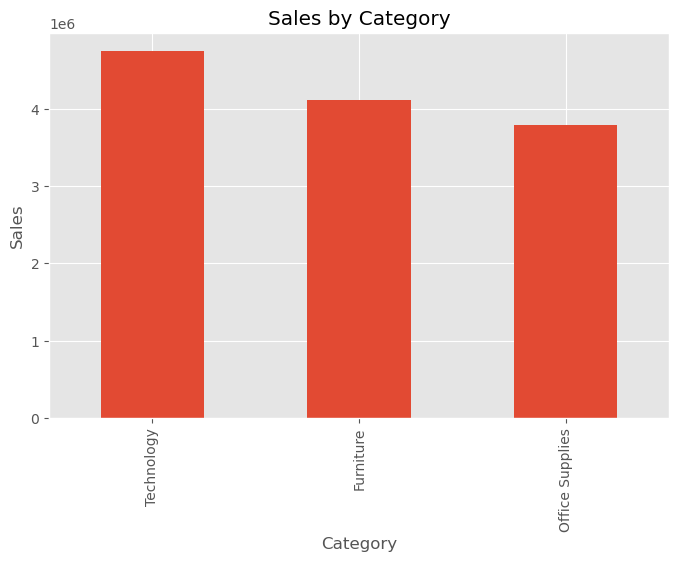

In [26]:
plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')

plt.show()

### Insight

Technology generated the highest sales revenue among all product categories, indicating strong customer demand for technology products.

Furniture ranked second in sales, while Office Supplies contributed the lowest revenue among the three categories.

## Analysis 2: Profit by Category

In [29]:
category_profit = df.groupby('category')['profit'].sum().sort_values(ascending=False)

category_profit

category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          285204.72380
Name: profit, dtype: float64

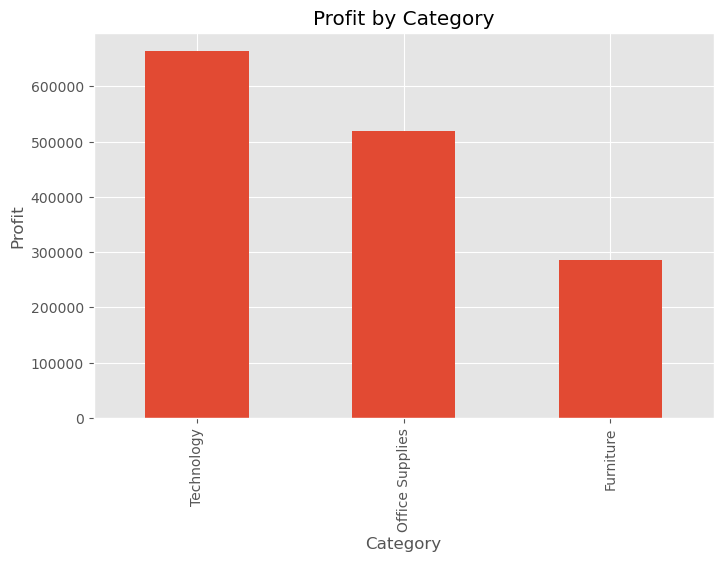

In [31]:
plt.figure(figsize=(8,5))

category_profit.plot(kind='bar')

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')

plt.show()

### Insight

Technology was also the most profitable category, generating the highest overall profit.

Although Furniture produced strong sales revenue, its profit was significantly lower than Office Supplies, suggesting lower profit margins or higher operating costs.

## Analysis 3: Monthly Sales Trend

In [44]:
monthly_sales = df.groupby('order_month')['sales'].sum()

monthly_sales

order_month
1      675141
2      543768
3      770519
4      698603
5      904061
6     1269751
7      749423
8     1293852
9     1437432
10    1168220
11    1551319
12    1580816
Name: sales, dtype: int64

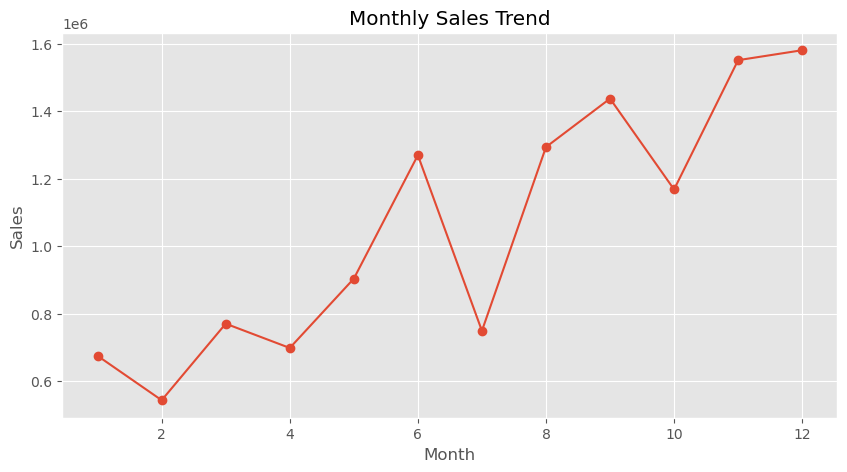

In [47]:
plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.show()

### Insight

Sales generally increased during the second half of the year, with the highest sales recorded in November and December.

This trend suggests a strong seasonal effect, where customer purchasing activity peaks toward the end of the year.

## Analysis 4: Top 10 Customers

In [50]:
top_customers = df.groupby(
    'customer_name'
)['sales'].sum().sort_values(
    ascending=False
).head(10)

top_customers

customer_name
Tom Ashbrook          40489
Tamara Chand          37453
Greg Tran             35552
Christopher Conant    35187
Sean Miller           35170
Bart Watters          32315
Natalie Fritzler      31778
Fred Hopkins          30404
Jane Waco             30288
Hunter Lopez          30246
Name: sales, dtype: int64

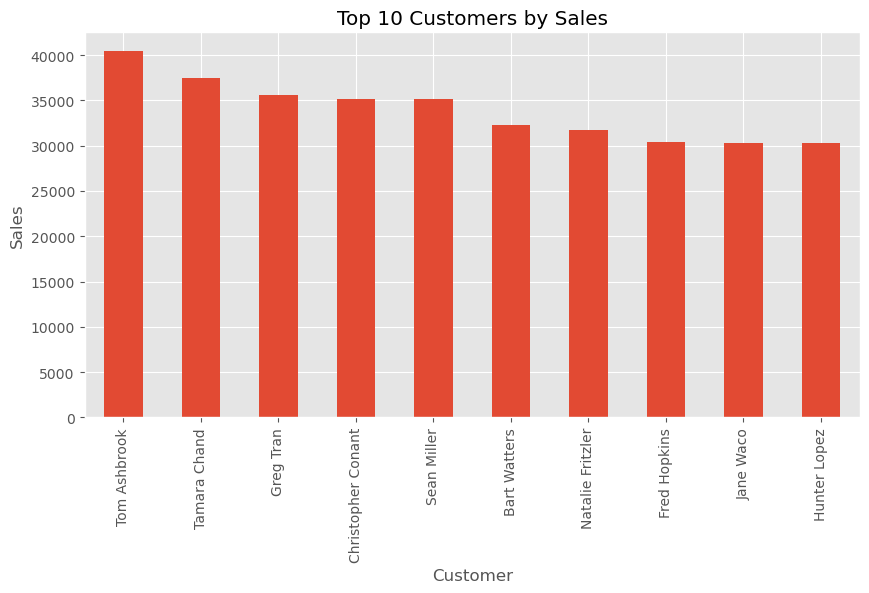

In [52]:
plt.figure(figsize=(10,5))

top_customers.plot(kind='bar')

plt.title('Top 10 Customers by Sales')
plt.xlabel('Customer')
plt.ylabel('Sales')

plt.show()

### Insight

A small group of customers contributed a substantial portion of total sales.

Tom Ashbrook was the highest revenue-generating customer, highlighting the importance of customer retention and targeted marketing strategies.

## Analysis 5: Regional Performance

In [55]:
regional_sales = df.groupby(
    'region'
)['sales'].sum().sort_values(
    ascending=False
)

regional_sales

region
Central           2822399
South             1600960
North             1248192
Oceania           1100207
Southeast Asia     884438
North Asia         848349
Emea               806184
Africa             783776
Central Asia       752839
West               725514
East               678834
Caribbean          324281
Canada              66932
Name: sales, dtype: int64

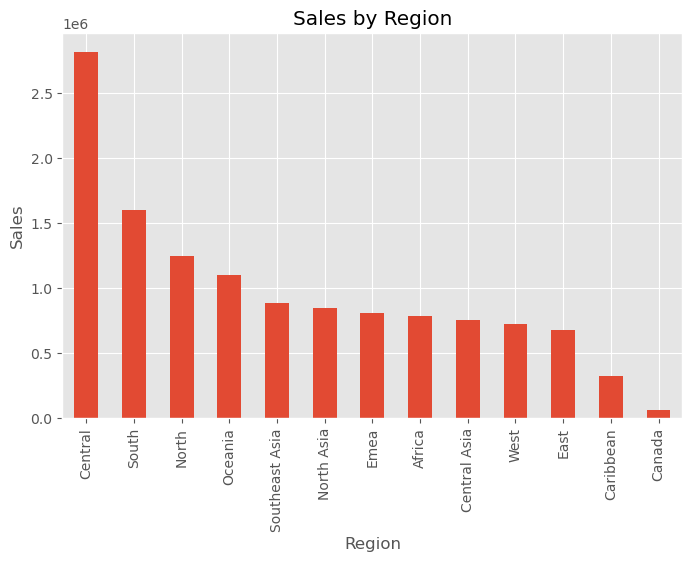

In [57]:
plt.figure(figsize=(8,5))

regional_sales.plot(kind='bar')

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')

plt.show()

### Insight

The Central region generated the highest sales revenue, significantly outperforming all other regions.

Canada recorded the lowest sales, indicating potential opportunities for market expansion or improved sales strategies.

## Analysis 6: Discount Impact on Profit

In [59]:
discount_profit = df.groupby(
    'discount_bin'
)['profit'].mean()

discount_profit

discount_bin
0-5%      62.051980
10-20%    27.614734
20-30%   -21.877573
30%+     -76.587827
5-10%     66.432594
Name: profit, dtype: float64

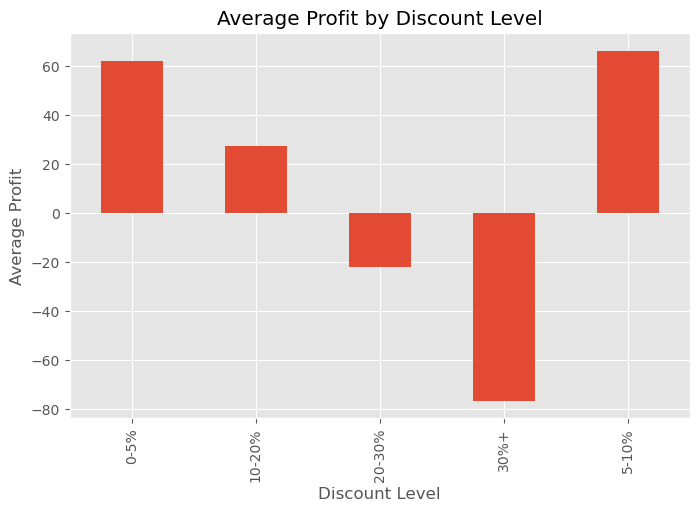

In [61]:
plt.figure(figsize=(8,5))

discount_profit.plot(kind='bar')

plt.title('Average Profit by Discount Level')
plt.xlabel('Discount Level')
plt.ylabel('Average Profit')

plt.show()

### Insight

Discounts between 0% and 10% generated the highest average profit.

Profitability declined sharply as discount levels increased. Discounts above 20% resulted in negative average profit, while discounts above 30% generated the largest losses.

This suggests that excessive discounting negatively impacts business performance and should be carefully controlled.

## Top 10 Products by Sales

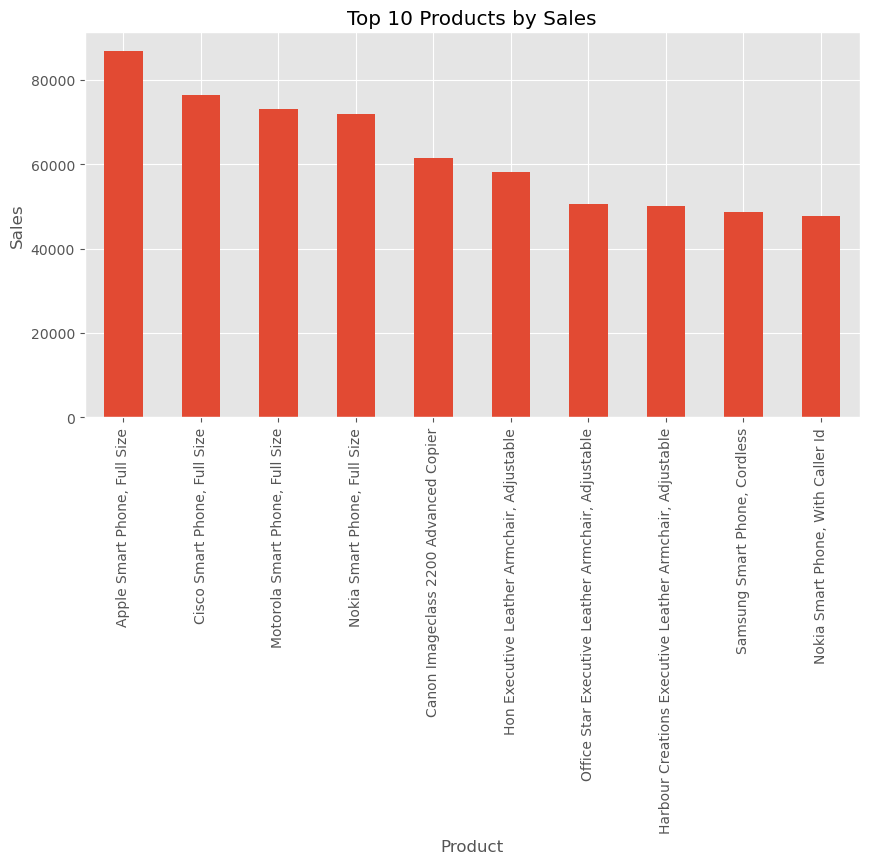

In [63]:
top_products = df.groupby(
    'product_name'
)['sales'].sum().sort_values(
    ascending=False
).head(10)

top_products.plot(kind='bar', figsize=(10,5))

plt.title('Top 10 Products by Sales')
plt.xlabel('Product')
plt.ylabel('Sales')

plt.show()

### Insight

Smart Phones were the highest revenue-generating products, dominating the top-selling product list.

Technology products occupied multiple positions among the top 10 products, confirming strong customer demand and reinforcing Technology as the highest-performing category.

## Conversion of type of Profit margin

In [67]:
df['profit_margin'].dtype

dtype('O')

In [69]:
df['profit_margin'] = pd.to_numeric(
    df['profit_margin'],
    errors='coerce'
)

In [71]:
df['profit_margin'].dtype

dtype('float64')

## Profit Margin by Category

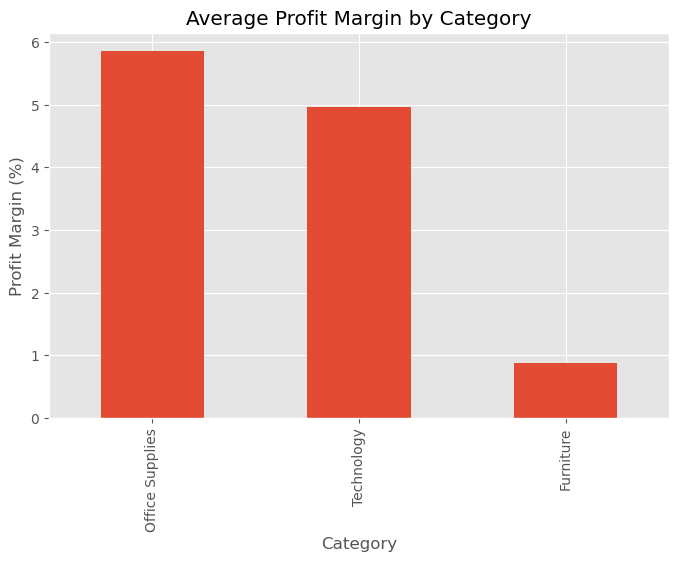

In [128]:
margin_category = df.groupby(
    'category'
)['profit_margin'].mean().sort_values(
    ascending=False
)

margin_category.plot(kind='bar', figsize=(8,5))

plt.title('Average Profit Margin by Category')
plt.xlabel('Category')
plt.ylabel('Profit Margin (%)')

plt.show()

### Insight 

Office Supplies achieved the highest average profit margin, indicating efficient profitability despite generating lower overall sales than Technology.

Furniture recorded the lowest profit margin, suggesting that this category may be affected by higher costs, aggressive discounting, or lower pricing efficiency.

# Key Findings

1. Technology was the highest revenue-generating and most profitable category.

2. Furniture generated strong sales but lower profit compared to Office Supplies.

3. Sales increased significantly during the final months of the year, indicating seasonal demand.

4. A small group of customers contributed a large share of total sales revenue.

5. The Central region was the strongest-performing market.

6. Discounts above 20% resulted in negative profitability.

7. Discounts between 0% and 10% delivered the highest average profit.

# Business Recommendations

1. Focus marketing efforts on Technology products due to their strong sales and profitability.

2. Investigate the low profit margins in the Furniture category and identify cost reduction opportunities.

3. Increase inventory and promotional campaigns during high-demand months such as November and December.

4. Develop loyalty programs for top-performing customers to improve retention.

5. Strengthen business presence in underperforming regions such as Canada.

6. Limit discount levels above 20% to prevent profitability losses.

7. Prioritize low-to-moderate discounts (0–10%) to maximize profit while maintaining sales volume.